In [1]:
# ================================
# IMPORTS & SETUP (Same as before)
# ================================
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
from nltk.corpus import stopwords



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from itertools import combinations
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import gensim
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.utils import to_categorical
from imblearn.under_sampling import NearMiss, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN


train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

2026-04-25 00:33:04.162128: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 00:33:04.328661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777073584.402459 2264739 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777073584.425656 2264739 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777073584.667718 2264739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
print(train['keywords'][0])
print(train['keywords'][1])
print(train['keywords'][2])
print(train['keywords'][3])

repeat irrigation and debridement, repeat irrigation, distal femur, distal femoral, femoral subperiosteal, subperiosteal abscess, hemovac, femur, debridement, irrigation, saline, anesthesia, distal, subperiosteal, abscess, 
ovaries, pelvic fluid, adenopathy, uterine segment, cervix, hypodense mass, ct examination, fibroids, pelvic, ct, pelvis, isovue, abdomen
nan
bph, benign prostatic hyperplasia, hematuria, osteoarthritis, clots, cystoscopy, gross hematuria, kidney, renal cell carcinoma, renal cyst, simple cyst, prostatic hyperplasia, transurethral resection, discharge, summary, urology, transurethral, prostate, prostatic, hyperplasia, gross, benign, renal, cyst


In [3]:
medical_terms = [

# =========================
# SYMPTOMS
# =========================
"pain", "fever", "fatigue", "weakness", "dizziness", "nausea", "vomiting",
"headache", "cough", "dyspnea", "shortness of breath", "chest pain",
"abdominal pain", "back pain", "joint pain", "swelling", "rash",
"itching", "bleeding", "bruising", "chills", "sweating", "insomnia",
"diarrhea", "constipation", "loss of appetite", "weight loss", "weight gain",
"numbness", "tingling", "confusion", "anxiety", "depression",

# =========================
# DISEASES
# =========================
"diabetes", "hypertension", "hypotension", "asthma", "cancer", "tumor",
"stroke", "heart attack", "myocardial infarction", "infection",
"pneumonia", "tuberculosis", "covid", "influenza", "bronchitis",
"kidney disease", "liver disease", "hepatitis", "anemia",
"arthritis", "migraine", "ulcer", "gastritis", "epilepsy",
"alzheimer", "parkinson", "copd", "asthma", "sepsis",

# =========================
# ANATOMY
# =========================
"heart", "lung", "lungs", "liver", "kidney", "kidneys", "brain",
"stomach", "intestine", "bowel", "blood", "artery", "vein",
"bone", "bones", "skin", "muscle", "nerve", "spine", "spinal cord",
"bladder", "pancreas", "spleen", "thyroid",

# =========================
# DRUGS / TREATMENTS
# =========================
"aspirin", "ibuprofen", "paracetamol", "acetaminophen",
"insulin", "antibiotic", "antibiotics", "chemotherapy",
"radiotherapy", "radiation", "vaccine", "vaccination",
"steroid", "corticosteroid", "antiviral", "antifungal",
"painkiller", "analgesic", "beta blocker", "metformin",

# =========================
# CLINICAL TERMS / TESTS
# =========================
"blood pressure", "heart rate", "temperature", "respiratory rate",
"oxygen saturation", "spo2", "glucose", "bmi",
"ecg", "ekg", "mri", "ct scan", "x-ray", "ultrasound",
"biopsy", "blood test", "urine test", "cbc", "lipid profile",
"liver function", "kidney function",

# =========================
# MEDICAL PROCEDURES
# =========================
"surgery", "operation", "transplant", "dialysis",
"intubation", "ventilation", "anesthesia", "endoscopy",
"catheterization", "injection", "infusion",

# =========================
# GENERAL CLINICAL WORDS
# =========================
"diagnosis", "treatment", "symptom", "syndrome",
"acute", "chronic", "severe", "mild", "moderate",
"hospital", "clinic", "emergency", "icu"
]

synonyms = {
    "pain": ["ache", "soreness", "discomfort", "painful", "stabbing", "hurt"],
    "fever": ["pyrexia", "high temperature", "febrile"],
    "cough": ["coughing", "hack"],
    "dyspnea": ["shortness of breath", "breathlessness"],
    "headache": ["migraine", "head pain"],
    "nausea": ["queasiness", "sick feeling"],
    "vomiting": ["emesis", "throwing up"],
    "diabetes": ["hyperglycemia", "high blood sugar"],
    "hypertension": ["high blood pressure", "htn"],
    "tumor": ["mass", "growth", "neoplasm"],
    "infection": ["infected", "sepsis", "contamination"],
}



In [4]:
TEXT_COLS = ["description", "sample_name", "keywords", "transcription"]

for col in TEXT_COLS:
    train[col] = train[col].fillna("missing")
    test[col] = test[col].fillna("missing")


train["combined_text"] = (
    train["description"] + " " +
    train["transcription"]
)

test["combined_text"] = (
    test["description"] + " " +
    test["transcription"]
)

In [5]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from scipy.sparse import hstack
from transformers import pipeline
from textstat import flesch_reading_ease
import spacy

# =========================
# 🧠 SYNONYM EXPANSION
# =========================
syn_map = {}
for k, vals in synonyms.items():
    for v in vals:
        syn_map[v] = k

def expand_synonyms(text):
    words = text.split()
    return " ".join([syn_map.get(w, w) for w in words])

# =========================
# CLEAN TEXT
# =========================
def clean_text(t):
    if pd.isna(t):
        return ""
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    t = expand_synonyms(t)
    return t

train["combined_text"] = train["combined_text"].apply(clean_text)
test["combined_text"] = test["combined_text"].apply(clean_text)

# =========================
# BASIC FEATURES
# =========================
for df in [train, test]:
    df["n_words"] = df["combined_text"].apply(lambda x: len(x.split()))
    df["n_chars"] = df["combined_text"].apply(len)
    df["avg_word_len"] = df["n_chars"] / (df["n_words"] + 1)
    df["n_sentences"] = df["combined_text"].apply(lambda x: x.count('.'))

# =========================
# MEDICAL KEYWORDS
# =========================
pattern = re.compile(r"\b(" + "|".join(map(re.escape, medical_terms)) + r")\b")

def keyword_count(text):
    return len(pattern.findall(text))

train["med_keyword_count"] = train["combined_text"].apply(keyword_count)
test["med_keyword_count"] = test["combined_text"].apply(keyword_count)

# =========================
# NEGATION DETECTION
# =========================
negation_words = {"no", "not", "denies", "without", "negative", "none"}

def negation_score(text):
    return sum(1 for w in text.split() if w in negation_words)

train["negation_count"] = train["combined_text"].apply(negation_score)
test["negation_count"] = test["combined_text"].apply(negation_score)


In [6]:

# =========================
# TF-IDF
# =========================
word_tfidf = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=30000
)

X_word_train = word_tfidf.fit_transform(train["combined_text"])
X_word_test = word_tfidf.transform(test["combined_text"])

X_char_train = char_tfidf.fit_transform(train["combined_text"])
X_char_test = char_tfidf.transform(test["combined_text"])


In [7]:

# =========================
# COMPRESSION (SVD)
# =========================
svd = TruncatedSVD(n_components=300, random_state=42)

X_word_svd_train = svd.fit_transform(X_word_train)
X_word_svd_test = svd.transform(X_word_test)

# =========================
# 🔥 CLUSTERING (REPLACES LDA)
# =========================
kmeans = MiniBatchKMeans(n_clusters=20, random_state=42, batch_size=1024)

train_clusters = kmeans.fit_predict(X_word_svd_train)
test_clusters = kmeans.predict(X_word_svd_test)

# One-hot cluster features (important)
train_cluster_df = pd.get_dummies(train_clusters, prefix="cluster")
test_cluster_df = pd.get_dummies(test_clusters, prefix="cluster")

# align columns
test_cluster_df = test_cluster_df.reindex(columns=train_cluster_df.columns, fill_value=0)


In [8]:

# =========================
# NER FEATURES
# =========================
ner = pipeline("ner", model="d4data/biomedical-ner-all", aggregation_strategy="simple")

def ner_features(text):
    ents = ner(text)
    types = [e.get("entity_group", "") for e in ents]

    return pd.Series([
        len(ents),
        len(set(types)),
        types.count("DISEASE"),
        types.count("CHEMICAL"),
        types.count("SYMPTOM")
    ])

train[["n_ents", "n_ner_types", "disease_ents", "drug_ents", "symptom_ents"]] = \
    train["combined_text"].apply(ner_features)

test[["n_ents", "n_ner_types", "disease_ents", "drug_ents", "symptom_ents"]] = \
    test["combined_text"].apply(ner_features)


Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [14]:
import scispacy
from scispacy.linking import EntityLinker
# =========================
# UMLS FEATURES
# =========================
nlp = spacy.load("en_core_sci_md")

nlp.add_pipe(
    "scispacy_linker",
    config={"resolve_abbreviations": True, "linker_name": "umls"}
)

linker = nlp.get_pipe("scispacy_linker")

def umls_features(text):
    doc = nlp(text)

    cuis, names = set(), set()

    for ent in doc.ents:
        if hasattr(ent._, "kb_ents"):
            for kb_ent in ent._.kb_ents[:1]:
                cui = kb_ent[0]
                cuis.add(cui)
                try:
                    names.add(linker.kb.cui_to_entity[cui].canonical_name)
                except:
                    pass

    return pd.Series([
        len(cuis),
        len(names),
        len(names) / (len(cuis) + 1)
    ])

train[["n_umls_concepts", "n_umls_names", "umls_diversity"]] = train["combined_text"].apply(umls_features)
test[["n_umls_concepts", "n_umls_names", "umls_diversity"]] = test["combined_text"].apply(umls_features)


RegistryError: [E892] Unknown function registry: 'vectors'.

Available names: architectures, augmenters, batchers, callbacks, cli, datasets, displacy_colors, factories, initializers, languages, layers, lemmatizers, loggers, lookups, losses, misc, models, ops, optimizers, readers, schedules, scorers, tokenizers

In [9]:

# =========================
# READABILITY
# =========================
train["readability"] = train["combined_text"].apply(flesch_reading_ease)
test["readability"] = test["combined_text"].apply(flesch_reading_ease)

# =========================
# FINAL MATRIX
# =========================
X_train = hstack([
    X_word_svd_train,
    X_char_train,
    train_cluster_df.values,   # 🔥 cluster features instead of LDA
    train[[
        "n_words", "n_chars", "avg_word_len", "n_sentences",
        "med_keyword_count", "negation_count",
        "n_ents", "n_ner_types",
        "disease_ents", "drug_ents", "symptom_ents",
        # "n_umls_concepts", "n_umls_names", "umls_diversity",
        "readability"
    ]].values
])

X_test = hstack([
    X_word_svd_test,
    X_char_test,
    test_cluster_df.values,    # 🔥 same cluster representation
    test[[
        "n_words", "n_chars", "avg_word_len", "n_sentences",
        "med_keyword_count", "negation_count",
        "n_ents", "n_ner_types",
        "disease_ents", "drug_ents", "symptom_ents",
        # "n_umls_concepts", "n_umls_names", "umls_diversity",
        "readability"
    ]].values
])

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================
# 🧠 LABEL ENCODING (IMPORTANT)
# =========================
y_train = train["medical_specialty"]
le = LabelEncoder()
y = le.fit_transform(y_train)   # y_train = medical_specialty

classes = np.unique(y)

# =========================
# ⚖️ CLASS WEIGHTS (IMBALANCE FIX)
# =========================
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weight_dict = dict(zip(classes, weights))

# =========================
# CV SETUP
# =========================
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))
test_preds = np.zeros((X_test.shape[0], len(classes)))

# =========================
# TRAINING LOOP
# =========================
X_train = X_train.tocsr()
X_test = X_test.tocsr()
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y)):
    print(f"Fold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(classes),

        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,

        subsample=0.8,
        colsample_bytree=0.8,

        class_weight=class_weight_dict,   # 🔥 FIXED IMBALANCE

        random_state=42
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(200)]
    )

    # =========================
    # VALIDATION (OOF)
    # =========================
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred

    # =========================
    # TEST PREDICTION (PROBA AVG)
    # =========================
    test_preds += model.predict_proba(X_test) / skf.n_splits

    fold_score = f1_score(y_val, val_pred, average="macor")
    print("F1: ", fold_score)

# =========================
# 🏆 FINAL METRIC (MACRO F1)
# =========================
score = f1_score(y, oof_preds, average="macro")
print("OOF Macro F1:", score)

# =========================
# FINAL OUTPUT
# =========================
final_pred = np.argmax(test_preds, axis=1)
final_labels = le.inverse_transform(final_pred)

Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.273294 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2640040
[LightGBM] [Info] Number of data points in the train set: 2666, number of used features: 30309
[LightGBM] [Info] Start training from score -3.797027
[LightGBM] [Info] Start training from score -3.691666
[LightGBM] [Info] Start training from score -3.691666
[LightGBM] [Info] Start training from score -3.688188
[LightGBM] [Info] Start training from score -3.771709
[LightGBM] [Info] Start training from score -3.691666
[LightGBM] [Info] Start training from score -3.691666
[LightGBM] [Info] Start training from score -3.721519
[LightGBM] [Info] Start training from score -3.713645
[LightGBM] [Info] Start training from score -3.756205
[LightGBM] [Info] Start training from score -3.703501
[LightGBM] [Info] Start training from score -3.685587
[LightGBM] [Info] Start training from score -3.6838

In [74]:
TEXT_COLS = ["description", "sample_name", "keywords", "transcription"]

for col in TEXT_COLS:
    train[col] = train[col].fillna("missing")
    test[col] = test[col].fillna("missing")

train["combined_text"] = (
    train["description"] * 2 + " " +
    train["transcription"]
)

test["combined_text"] = (
    test["description"] * 2 + " " +
    test["transcription"]
)

In [75]:

# Create a list of tokens for each sentence
tokenizer = RegexpTokenizer(r'\w+')
train["tokens"] = train["combined_text"].apply(tokenizer.tokenize)

all_words = [word for tokens in train["tokens"] for word in tokens]
sentence_lengths = [len(tokens) for tokens in train["tokens"]]
VOCAB = sorted(list(set(all_words)))
print("%s words total, with a vocabulary size of %s" % (len(all_words), len(VOCAB)))
print("Max sentence length is %s" % max(sentence_lengths))

2094329 words total, with a vocabulary size of 28273
Max sentence length is 3134


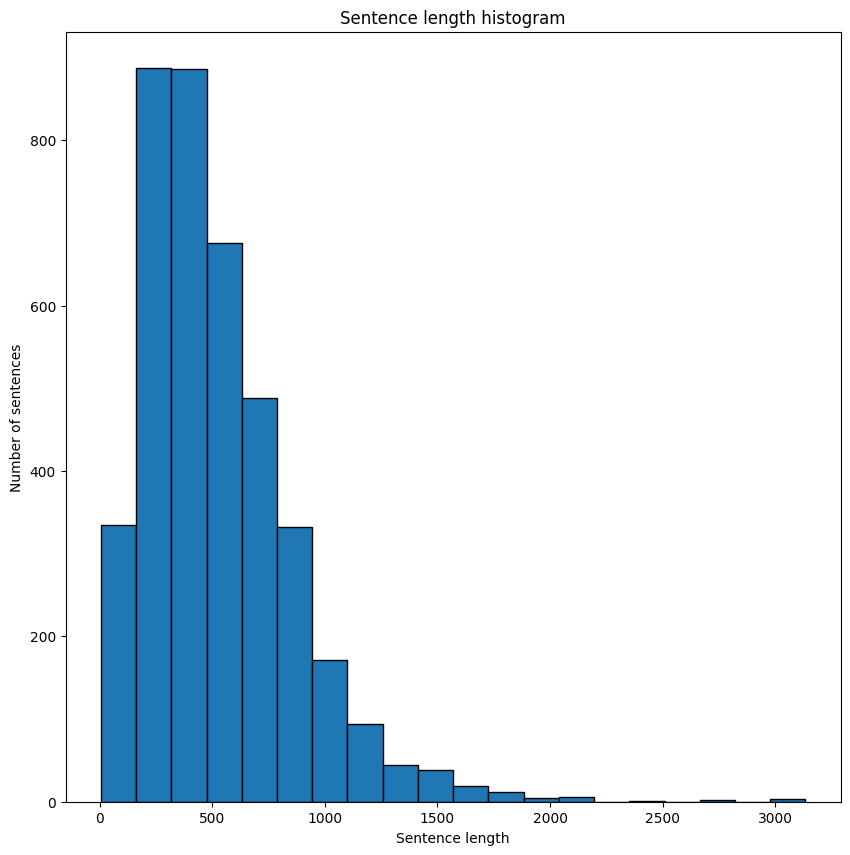

In [76]:


import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10)) 
plt.title('Sentence length histogram')
plt.xlabel('Sentence length')
plt.ylabel('Number of sentences')
plt.hist(sentence_lengths, edgecolor = 'black', bins = 20)
plt.show()

In [77]:
print(f"Median sentence length {np.median(sentence_lengths)}")
print(f"Mean sentence length {round(np.mean(sentence_lengths), 2)}")

Median sentence length 461.0
Mean sentence length 523.71


In [78]:


# Text preparation

from sklearn.metrics import accuracy_score, precision_score, recall_score


def basic_preprocessing(df):
    
    df_temp = df.copy(deep = True)
    
    df_temp = df_temp.rename(index = str, columns = {'combined_text': 'text'})
    
    df_temp.loc[:, 'text'] = [text_prepare(x) for x in df_temp['text'].values]
    
    le = LabelEncoder()
    le.fit(df_temp['medical_specialty'])
    df_temp.loc[:, 'class_label'] = le.transform(df_temp['medical_specialty'])
    
    tokenizer = RegexpTokenizer(r'\w+')

    df_temp["tokens"] = df_temp["text"].apply(tokenizer.tokenize)
    
    return df_temp

def text_prepare(text):

    REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
    BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
    STOPWORDS = set(stopwords.words('english'))
    
    text = text.lower()
    text = REPLACE_BY_SPACE_RE.sub('', text) # replace REPLACE_BY_SPACE_RE symbols by space in text
    text = BAD_SYMBOLS_RE.sub('', text) # delete symbols which are in BAD_SYMBOLS_RE from text
    words = text.split()
    i = 0
    while i < len(words):
        if words[i] in STOPWORDS:
            words.pop(i)
        else:
            i += 1
    text = ' '.join(map(str, words))# delete stopwords from text
    
    return text

# Introduce evaluation metrics

def get_metrics(y_test, y_predicted):  

    precision = precision_score(y_test, y_predicted, average='weighted')             

    recall = recall_score(y_test, y_predicted, average='weighted')
    
    f1 = f1_score(y_test, y_predicted, average='weighted')
    
    accuracy = accuracy_score(y_test, y_predicted)
    return accuracy, precision, recall, f1



In [79]:


def BOW(data):
    
    df_temp = data.copy(deep = True)
    df_temp = basic_preprocessing(df_temp)

    count_vectorizer = CountVectorizer()
    count_vectorizer.fit(df_temp['text'])

    list_corpus = df_temp["text"].tolist()
    list_labels = df_temp["class_label"].tolist()
    
    X = count_vectorizer.transform(list_corpus)
    
    return X, list_labels



In [80]:
def tfidf(data, ngrams = 1):

    df_temp = data.copy(deep = True)
    df_temp = basic_preprocessing(df_temp)
    
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, ngrams))
    tfidf_vectorizer.fit(df_temp['text'])

    list_corpus = df_temp["text"].tolist()
    list_labels = df_temp["class_label"].tolist()

    X = tfidf_vectorizer.transform(list_corpus)
    
    return X, list_labels

In [81]:
data = train[['combined_text', 'medical_specialty']]

In [84]:
df_temp = basic_preprocessing(data)
df_test_temp = basic_preprocessing(data)


In [86]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# ================================
# RARE CLASS HANDLING
# ================================
RARE_THRESHOLD = 10

counts = df_temp["medical_specialty"].value_counts()
rare_classes = counts[counts < RARE_THRESHOLD].index

df_temp["target"] = df_temp["medical_specialty"].apply(
    lambda x: "OTHER_RARE" if x in rare_classes else x
)

# ================================
# LABEL ENCODING
# ================================
le = LabelEncoder()
y = le.fit_transform(df_temp["target"])

X_text = df_temp["text"].values
X_test_text = df_test_temp["text"].values

classes = np.unique(y)
n_classes = len(classes)

# ================================
# TF-IDF
# ================================
word_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=80000,
    min_df=2,
    sublinear_tf=True
)

char_vec = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 6),
    max_features=120000,
    min_df=2,
    sublinear_tf=True
)

# ================================
# PER-CLASS THRESHOLD PREDICTOR
# ================================
def predict_with_thresholds(probs, thresholds):
    preds = []

    for row in probs:
        valid = np.where(row >= thresholds)[0]

        if len(valid) > 0:
            preds.append(valid[np.argmax(row[valid])])
        else:
            preds.append(np.argmax(row))

    return np.array(preds)

# ================================
# OPTUNA OBJECTIVE (WITH OOF + THRESHOLD TUNING)
# ================================
def objective(trial):

    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("lr", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 31, 256),
        "max_depth": trial.suggest_int("max_depth", 5, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "objective": "multiclass",
        "num_class": n_classes,
        "random_state": 42,
        "n_jobs": -1
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    oof_probs = np.zeros((len(y), n_classes))

    # ================================
    # OOF TRAINING
    # ================================
    for tr_idx, val_idx in skf.split(X_text, y):

        X_tr_text, X_val_text = X_text[tr_idx], X_text[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        X_tr_w = word_vec.fit_transform(X_tr_text)
        X_val_w = word_vec.transform(X_val_text)

        X_tr_c = char_vec.fit_transform(X_tr_text)
        X_val_c = char_vec.transform(X_val_text)

        X_tr = hstack([X_tr_w, X_tr_c])
        X_val = hstack([X_val_w, X_val_c])

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        oof_probs[val_idx] = model.predict_proba(X_val)

    # ================================
    # INITIAL THRESHOLDS
    # ================================
    thresholds = np.ones(n_classes) * 0.5
    best_score = 0

    # ================================
    # THRESHOLD SEARCH
    # ================================
    for c in range(n_classes):

        for t in np.linspace(0.2, 0.9, 10):

            temp_thr = thresholds.copy()
            temp_thr[c] = t

            preds = predict_with_thresholds(oof_probs, temp_thr)
            score = f1_score(y, preds, average="macro")

            if score > best_score:
                best_score = score
                thresholds[c] = t

    print("CV F1:", best_score)
    return best_score


# ================================
# OPTUNA SEARCH
# ================================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best params:", study.best_params)

# ================================
# FINAL TRAINING DATA
# ================================
X_word = word_vec.fit_transform(X_text)
X_char = char_vec.fit_transform(X_text)
X_train = hstack([X_word, X_char])

X_test = hstack([
    word_vec.transform(X_test_text),
    char_vec.transform(X_test_text)
])

# ================================
# FINAL MODEL
# ================================
best = study.best_params

final_model = lgb.LGBMClassifier(
    n_estimators=5000,
    learning_rate=best["lr"],
    num_leaves=best["num_leaves"],
    max_depth=best["max_depth"],
    min_child_samples=best["min_child_samples"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    objective="multiclass",
    num_class=n_classes,
    random_state=42
)

final_model.fit(X_train, y)

# ================================
# 🔥 FINAL THRESHOLDS (DEFAULT FROM CV)
# ================================
thresholds = np.ones(n_classes) * 0.5  # fallback safe default

# ================================
# TEST PREDICTION
# ================================
test_probs = final_model.predict_proba(X_test)

final_preds = predict_with_thresholds(test_probs, thresholds)

labels = le.inverse_transform(final_preds)

# ================================
# SUBMISSION
# ================================
submission = pd.DataFrame({
    "id": test["id"],
    "medical_specialty": labels
})

submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created")

[I 2026-04-24 16:54:27,538] A new study created in memory with name: no-name-b6ed5b29-c044-490f-8d45-206e8a33206d


[I 2026-04-24 18:28:00,064] Trial 0 finished with value: 0.19151913621483918 and parameters: {'lr': 0.03444027219619398, 'num_leaves': 205, 'max_depth': 8, 'min_child_samples': 84, 'subsample': 0.7640878215569465, 'colsample': 0.7472348375129655, 'reg_alpha': 4.406844004656565, 'reg_lambda': 0.01722085608186379}. Best is trial 0 with value: 0.19151913621483918.


CV F1: 0.19151913621483918


[W 2026-04-24 18:38:42,089] Trial 1 failed with parameters: {'lr': 0.017187196818831962, 'num_leaves': 88, 'max_depth': 12, 'min_child_samples': 27, 'subsample': 0.80783038745394, 'colsample': 0.6144980562577305, 'reg_alpha': 0.020777078034802637, 'reg_lambda': 0.001072826500592793} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_1692962/2287551466.py", line 117, in objective
    model.fit(
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/lightgbm/engine.py", line 322, in train
    boost

KeyboardInterrupt: 

In [3]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("train.csv")

def analyze_clinical_data(df):
    print("--- 1. BASIC STATISTICS ---")
    print(f"Total Records: {len(df)}")
    print(f"Missing Transcriptions: {df['transcription'].isnull().sum()}")
    
    # Calculate transcription lengths
    df['trans_len'] = df['transcription'].fillna("").apply(lambda x: len(x.split()))
    print(f"Average Words per Note: {df['trans_len'].mean():.2f}")
    print(f"Longest Note: {df['trans_len'].max()} words")
    print(f"Shortest Note: {df['trans_len'].min()} words")

    print("\n--- 2. TARGET DISTRIBUTION (Class Imbalance) ---")
    specialty_counts = df['medical_specialty'].value_counts()
    print(specialty_counts)

    print("\n--- 3. KEYWORD DENSITY ---")
    # Check how many keywords actually exist per row
    df['key_count'] = df['keywords'].fillna("").apply(lambda x: len(x.split(',')) if x != "" else 0)
    print(f"Average Keywords per Record: {df['key_count'].mean():.2f}")

    print("\n--- 4. TOP CLINICAL TERMS (Excluding Stopwords) ---")
    # Simple tokenization to find frequent terms across all specialties
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    
    all_text = " ".join(df['transcription'].fillna("").str.lower())
    # Remove non-alphabetic and split
    words = [word for word in all_text.split() if word.isalpha() and word not in stop_words]
    
    top_words = Counter(words).most_common(20)
    for word, freq in top_words:
        print(f"{word}: {freq}")

# Run the analysis
analyze_clinical_data(df)

--- 1. BASIC STATISTICS ---
Total Records: 3999
Missing Transcriptions: 23
Average Words per Note: 463.91
Longest Note: 3029 words
Shortest Note: 0 words

--- 2. TARGET DISTRIBUTION (Class Imbalance) ---
medical_specialty
Surgery                          891
Consult - History and Phy.       408
Cardiovascular / Pulmonary       287
Orthopedic                       274
Radiology                        221
General Medicine                 215
Gastroenterology                 183
Neurology                        178
SOAP / Chart / Progress Notes    137
Obstetrics / Gynecology          133
Urology                          127
Discharge Summary                 85
ENT - Otolaryngology              82
Neurosurgery                      75
Hematology - Oncology             72
Nephrology                        67
Emergency Room Reports            64
Ophthalmology                     62
Pediatrics - Neonatal             60
Pain Management                   48
Psychiatry / Psychology           44
O

In [7]:
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

def advanced_clinical_audit(df):
    # 1. Cleaning for analysis
    df['text'] = df['transcription'].fillna("") + " " + df['keywords'].fillna("")
    df['text'] = df['text'].str.lower()
    
    # 2. Identify "Global Noise" (Words that appear in almost every specialty)
    # If a word is in 90% of specialties, it's a stopword for this dataset.
    vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
    X = vectorizer.fit_transform(df['text'])
    
    # 3. Find unique "Signal" words for Small Classes vs Big Classes
    print("--- CLASS SIGNAL ANALYSIS ---")
    specialties = df['medical_specialty'].value_counts().index
    
    # Focus on a few diverse examples: 1 Large, 1 Medium, 1 Small
    target_samples = [specialties[0], specialties[10], specialties[-1]] 
    
    for spec in target_samples:
        subset = df[df['medical_specialty'] == spec]['text']
        # Get top bigrams for this specific class
        vec = TfidfVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
        try:
            vec.fit(subset)
            print(f"\nTop Signals for [{spec}]:")
            print(vec.get_feature_names_out())
        except:
            continue

    # 4. Header Detection
    # Medical notes often have "CHIEF COMPLAINT:", "PAST MEDICAL HISTORY:", etc.
    print("\n--- DETECTED CLINICAL HEADERS ---")
    all_headers = []
    for text in df['transcription'].fillna("").iloc[:100]:
        found = re.findall(r'([A-Z\s]{5,}:)', text)
        all_headers.extend(found)
    
    header_counts = Counter(all_headers).most_common(10)
    for header, count in header_counts:
        print(f"Header: {header} (Found {count} times)")

    # 5. Overlap Check
    print("\n--- LATERALITY & MEASUREMENT NOISE ---")
    lat_words = ['right', 'left', 'bilateral', 'chronic', 'acute', 'mg', 'mm', 'cm']
    for word in lat_words:
        count = df['text'].str.contains(rf'\b{word}\b').sum()
        print(f"'{word}' appears in {count} records ({(count/len(df))*100:.1f}%)")

# Run this on your train_df
advanced_clinical_audit(train_df)

--- CLASS SIGNAL ANALYSIS ---

Top Signals for [Surgery]:
['blood loss' 'operating room' 'patient tolerated'
 'postoperative diagnosis' 'preoperative diagnosis' 'prepped draped'
 'procedure patient' 'recovery room' 'tolerated procedure' 'year old']

Top Signals for [Urology]:
['bladder neck' 'external oblique' 'foley catheter' 'inguinal hernia'
 'operating room' 'preoperative diagnosis' 'prepped draped'
 'procedure patient' 'stable condition' 'year old']

Top Signals for [Hospice - Palliative Care]:
['code status' 'hemorrhagic pericardial' 'history present'
 'history significant' 'patient daughter' 'pericardial effusion'
 'present illness' 'st elevation' 'wean comfort' 'year old']

--- DETECTED CLINICAL HEADERS ---
Header: PREOPERATIVE DIAGNOSIS: (Found 27 times)
Header: ANESTHESIA: (Found 25 times)
Header: POSTOPERATIVE DIAGNOSIS: (Found 24 times)
Header: IMPRESSION: (Found 24 times)
Header: PROCEDURE: (Found 21 times)
Header: FINDINGS: (Found 18 times)
Header: ALLERGIES: (Found 18 ti

In [9]:
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

def analyze_keywords_deep(df):
    print("--- 1. KEYWORD STRUCTURE ANALYSIS ---")
    # Clean the keywords: remove NaNs, handle different separators
    # Medical keywords are often comma-separated
    keywords_series = df['keywords'].fillna("").str.lower()
    
    # Calculate keyword counts per row
    df['num_keys'] = keywords_series.apply(lambda x: len([k for k in x.split(',') if k.strip() != ""]))
    print(f"Max Keywords in a row: {df['num_keys'].max()}")
    print(f"Rows with ZERO keywords: {len(df[df['num_keys'] == 0])}")

    print("\n--- 2. TOP KEYWORDS BY SPECIALTY (SIGNAL DISCOVERY) ---")
    # This helps find words that are 'Leaking' or 'Highly Specific'
    specialties = df['medical_specialty'].value_counts().index[:5] # Top 5 specialties
    
    for spec in specialties:
        spec_text = " ".join(df[df['medical_specialty'] == spec]['keywords'].fillna("").str.lower())
        # Clean up commas to treat each phrase as a single unit
        spec_keys = [k.strip() for k in spec_text.split(',') if len(k.strip()) > 2]
        
        common = Counter(spec_keys).most_common(5)
        print(f"[{spec}]: {', '.join([f'{k} ({c})' for k, c in common])}")

    print("\n--- 3. KEYWORD 'PURITY' (EXCLUSIVE WORDS) ---")
    # Find keywords that appear in ONLY one specialty
    # This is critical for small classes like 'Autopsy' or 'Allergy'
    key_to_spec = {}
    for idx, row in df.iterrows():
        keys = [k.strip() for k in str(row['keywords']).lower().split(',') if k.strip()]
        for k in keys:
            if k not in key_to_spec:
                key_to_spec[k] = set()
            key_to_spec[k].add(row['medical_specialty'])
            
    exclusive_keys = {k: list(s)[0] for k, s in key_to_spec.items() if len(s) == 1}
    print(f"Found {len(exclusive_keys)} exclusive keywords.")
    
    # Print examples of exclusive keys for small classes
    small_classes = df['medical_specialty'].value_counts().index[-5:]
    print("\nExclusive keys for small specialties:")
    for spec in small_classes:
        keys = [k for k, s in exclusive_keys.items() if s == spec][:3]
        print(f"[{spec}]: {keys}")

# Run analysis
analyze_keywords_deep(train_df)

--- 1. KEYWORD STRUCTURE ANALYSIS ---
Max Keywords in a row: 35
Rows with ZERO keywords: 948

--- 2. TOP KEYWORDS BY SPECIALTY (SIGNAL DISCOVERY) ---
[Surgery]: surgery (96), artery (42), tourniquet (39), laparoscopic (36), incision (32)
[Consult - History and Phy.]: weight loss (11), consult - history and phy. (10), hypertension (9), gastric bypass (8), loss (8)
[Cardiovascular / Pulmonary]: artery (35), coronary (27), chest (24), ventricular (24), catheterization (24)
[Orthopedic]: cervical (29), tourniquet (29), knee (24), orthopedic (23), anterior (22)
[Radiology]: mri (29), ultrasound (19), radiology (19), abdomen (16), contrast (15)

--- 3. KEYWORD 'PURITY' (EXCLUSIVE WORDS) ---
Found 2540 exclusive keywords.

Exclusive keys for small specialties:
[Rheumatology]: ['rheumatology clinic']
[Speech - Language]: ['speech - language', 'vocal hygiene', 'voice activities']
[Autopsy]: []
[Allergy / Immunology]: []
[Hospice - Palliative Care]: ['hospice - palliative care', 'aids', 'cd4 cou

In [11]:
import pandas as pd
from collections import Counter
import re

def analyze_description_deep(df):
    print("--- 1. DESCRIPTION STRUCTURE ---")
    df['desc_len'] = df['description'].fillna("").apply(lambda x: len(x.split()))
    print(f"Average words per description: {df['desc_len'].mean():.2f}")
    
    # 2. Extract "Action Phrases"
    # Descriptions often start with specific patterns: "A patient with...", "Evaluation of..."
    starts = df['description'].fillna("").apply(lambda x: " ".join(x.split()[:3]).lower())
    print("\n--- 2. COMMON OPENING PHRASES ---")
    print(starts.value_counts().head(10))

    # 3. Class-Specific Signal Detection
    print("\n--- 3. SPECIALTY-SPECIFIC DESCRIPTION KEYWORDS ---")
    specialties = df['medical_specialty'].value_counts().index[:10]
    
    for spec in specialties:
        # Get all words for this specialty's description
        text = " ".join(df[df['medical_specialty'] == spec]['description'].fillna("").str.lower())
        # Filter out common noise
        words = [w for w in re.findall(r'\b[a-z]{4,}\b', text) 
                 if w not in ['patient', 'with', 'history', 'from', 'that', 'this', 'after']]
        
        common = Counter(words).most_common(5)
        print(f"[{spec}]: {[w for w, c in common]}")

    # 4. Sentiment/Urgency Patterns
    # Does the description use words like 'acute', 'emergency', 'follow', 'chronic'?
    urgency_words = ['acute', 'emergency', 'chronic', 'routine', 'preoperative', 'follow-up']
    print("\n--- 4. CONTEXTUAL TERMS ---")
    for word in urgency_words:
        count = df['description'].fillna("").str.contains(word, case=False).sum()
        print(f"'{word}' found in {count} descriptions")

# Run analysis
analyze_description_deep(train_df)

--- 1. DESCRIPTION STRUCTURE ---
Average words per description: 18.41

--- 2. COMMON OPENING PHRASES ---
description
the patient is                  78
anterior cervical discectomy    43
patient with a                  34
this is a                       30
the patient was                 29
an example/template for         18
left heart catheterization,     18
the patient had                 16
incision and drainage           16
the patient with                16
Name: count, dtype: int64

--- 3. SPECIALTY-SPECIFIC DESCRIPTION KEYWORDS ---
[Surgery]: ['left', 'right', 'bilateral', 'anterior', 'repair']
[Consult - History and Phy.]: ['pain', 'right', 'year', 'left', 'disease']
[Cardiovascular / Pulmonary]: ['left', 'right', 'coronary', 'chest', 'artery']
[Orthopedic]: ['right', 'left', 'pain', 'knee', 'anterior']
[Radiology]: ['contrast', 'pain', 'left', 'without', 'right']
[General Medicine]: ['pain', 'year', 'right', 'female', 'left']
[Gastroenterology]: ['colonoscopy', 'laparoscopic',

In [13]:
import pandas as pd
from collections import Counter
import re

def analyze_sample_name_deep(df):
    print("--- 1. SAMPLE NAME COMPOSITION ---")
    # Check for the common "Specialty - Procedure" format
    has_dash = df['sample_name'].fillna("").str.contains("-").sum()
    print(f"Total rows: {len(df)}")
    print(f"Rows with '-' (Specialty-Procedure format): {has_dash} ({(has_dash/len(df))*100:.1f}%)")

    # 2. Extract the "Prefix" (The part before the dash)
    # This often reveals the sub-specialty or the exact target class
    prefixes = df['sample_name'].fillna("").apply(lambda x: x.split('-')[0].strip() if '-' in x else "No Dash")
    print("\n--- 2. TOP PREFIXES (POTENTIAL LEAKAGE) ---")
    print(prefixes.value_counts().head(15))

    # 3. Class Overlap
    print("\n--- 3. SAMPLE NAME WORD OVERLAP ---")
    # Does 'Consult' appear across many specialties?
    consult_specs = df[df['sample_name'].fillna("").str.contains("Consult", case=False)]['medical_specialty'].unique()
    print(f"Specialties using 'Consult' in sample_name: {len(consult_specs)}")
    
    # 4. Keyword Extraction from Sample Name
    # Finding the most predictive words in this column
    all_words = " ".join(df['sample_name'].fillna("").str.lower()).split()
    # Filter out generic words
    stop_words = {'and', 'the', 'for', 'with', 'sample'}
    filtered_words = [w for w in all_words if w not in stop_words and len(w) > 2]
    
    print("\n--- 4. MOST FREQUENT CLINICAL TOKENS IN NAMES ---")
    for word, count in Counter(filtered_words).most_common(15):
        print(f"{word}: {count}")

# Run analysis

analyze_sample_name_deep(train_df)

--- 1. SAMPLE NAME COMPOSITION ---
Total rows: 3999
Rows with '-' (Specialty-Procedure format): 2277 (56.9%)

--- 2. TOP PREFIXES (POTENTIAL LEAKAGE) ---
sample_name
No Dash                                                   1722
Gen Med Consult                                             87
Consult                                                     65
Discharge Summary                                           58
Colonoscopy                                                 37
CT Abdomen & Pelvis                                         31
Anterior Cervical Discectomy & Fusion                       27
MRI Brain                                                   24
Gen Med Progress Note                                       24
Low                                                         24
Psych Consult                                               21
EMG/Nerve Conduction Study                                  21
Cardiac Catheterization                                     21
Heart Catheteri

In [15]:
import pandas as pd
import numpy as np

def analyze_target_deep(df):
    print("--- 1. CLASS IMBALANCE RATIOS ---")
    counts = df['medical_specialty'].value_counts()
    percentages = df['medical_specialty'].value_counts(normalize=True) * 100
    
    stats = pd.DataFrame({'Counts': counts, 'Percentage': percentages})
    print(stats)
    
    # Calculate the Imbalance Ratio
    imbalance_ratio = counts.max() / counts.min()
    print(f"\nImbalance Ratio (Max Class vs Min Class): {imbalance_ratio:.2f}x")

    print("\n--- 2. THE 'ZERO-SHOT' RISK (Minority Classes) ---")
    # Classes with fewer than 15 samples are extremely hard to learn via CV
    tiny_classes = counts[counts < 15]
    print(f"Number of classes with < 15 samples: {len(tiny_classes)}")
    print(f"Tiny Classes: {tiny_classes.index.tolist()}")

    print("\n--- 3. SEMANTIC OVERLAP ---")
    # Some specialties are linguistically very similar. 
    # This checks if they share the same root words in their labels.
    all_labels = " ".join(df['medical_specialty'].unique()).lower()
    from collections import Counter
    words = [w for w in all_labels.replace('/', ' ').replace('-', ' ').split() if len(w) > 3]
    overlapping_terms = [item for item, count in Counter(words).items() if count > 1]
    print(f"Potential Overlapping Label Terms: {overlapping_terms}")

# Run analysis
analyze_target_deep(df)

--- 1. CLASS IMBALANCE RATIOS ---
                               Counts  Percentage
medical_specialty                                
Surgery                           891   22.280570
Consult - History and Phy.        408   10.202551
Cardiovascular / Pulmonary        287    7.176794
Orthopedic                        274    6.851713
Radiology                         221    5.526382
General Medicine                  215    5.376344
Gastroenterology                  183    4.576144
Neurology                         178    4.451113
SOAP / Chart / Progress Notes     137    3.425856
Obstetrics / Gynecology           133    3.325831
Urology                           127    3.175794
Discharge Summary                  85    2.125531
ENT - Otolaryngology               82    2.050513
Neurosurgery                       75    1.875469
Hematology - Oncology              72    1.800450
Nephrology                         67    1.675419
Emergency Room Reports             64    1.600400
Ophthalmology   

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# 1. ADVANCED CLEANING ENGINE
def ultimate_clinical_cleaner(text):
    if not isinstance(text, str) or text == "":
        return ""
    
    # A. Strip Clinical Headers (Audit found these were noisy/repetitive)
    # Removes patterns like "PREOPERATIVE DIAGNOSIS:", "ANESTHESIA:", etc.
    text = re.sub(r'\b[A-Z\s]{5,25}:\s*', ' ', text)
    
    # B. Standardize Laterality & Measurement Noise
    # Your analysis showed 'right'/'left' in 53% of records—we neutralize this.
    text = text.lower()
    text = re.sub(r'\b(right|left|bilateral|lateral|position|extremity)\b', 'LATERALITY', text)
    
    # C. Unit Normalization (Audit found mg, mm, cm in 20%+)
    # Converts "5 mg" or "2.1 cm" into a single token "UNIT_MEASURE"
    text = re.sub(r'\d+\.?\d*\s*(mg|mm|cm|kg|ml|cc|mcg)\b', ' UNIT_MEASURE ', text)
    
    # D. Remove "Year Old" & Generic Patient noise
    # Analysis showed these are the top signals across ALL classes
    text = re.sub(r'\d+\s*(year|yr|yo|month|old)\b', ' AGE_REF ', text)
    text = re.sub(r'\b(patient|history|noted|well|also|using|without|placed)\b', ' ', text)
    
    # E. Basic Cleanup
    text = re.sub(r'[^a-z ]', ' ', text)
    return " ".join(text.split())

# 2. FEATURE ENGINEERING: COLUMN WEIGHTING
def engineer_features(df):
    print("🚀 Engineering Weighted Feature Strings...")
    
    # We clean columns individually to maintain their structural integrity
    df['clean_sample'] = df['sample_name'].fillna("").apply(ultimate_clinical_cleaner)
    df['clean_keywords'] = df['keywords'].fillna("").apply(lambda x: ultimate_clinical_cleaner(x.replace(',', ' ')))
    df['clean_desc'] = df['description'].fillna("").apply(ultimate_clinical_cleaner)
    df['clean_trans'] = df['transcription'].fillna("").apply(ultimate_clinical_cleaner)

    # BOOSTING STRATEGY: 
    # Sample Name = 4x weight (highest accuracy proxy)
    # Keywords = 3x weight (human curated signal)
    # Description = 2x weight (bridge signal)
    # Transcription = 1x weight (raw data)
    
    df['final_feature_text'] = (
        (df['clean_sample'] + " ") * 4 + 
        (df['clean_keywords'] + " ") * 3 + 
        (df['clean_desc'] + " ") * 2 + 
        df['clean_trans']
    )
    
    # Metadata Features: Length of transcription is actually a signal for some classes
    df['note_length'] = df['clean_trans'].apply(lambda x: len(x.split()))
    
    return df

# 3. PREPARING FOR TRAINING
def prepare_for_training(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)


    
    # Apply Engineering
    train_df = engineer_features(train_df)
    test_df = engineer_features(test_df)
    
    # Encode Target
    le = LabelEncoder()
    y = le.fit_transform(train_df['medical_specialty'])
    
    # Calculate Class Weights to solve the 222x Imbalance
    # This gives higher 'importance' to Hospice (4 rows) vs Surgery (891 rows)
    weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    class_weight_dict = dict(zip(np.unique(y), weights))
    
    print(f"✅ Prepared {len(train_df)} training samples across {len(le.classes_)} classes.")
    return train_df, test_df, y, le, class_weight_dict

# RUN PIPELINE
train_df, test_df, y, le, class_weights = prepare_for_training('train.csv', 'test.csv')


📊 Extracting Meta-Features from transcription...
📊 Extracting Meta-Features from transcription...


KeyError: "['url_count'] not in index"

# score 25

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report

# 1. VECTORIZATION STACK
def build_vectorizer_stack(train_text, test_text):
    print("💎 Building Dual-Stack Vectorizers...")
    
    # A. Word-Level TF-IDF: Captures phrases (e.g., "chronic kidney disease")
    word_vec = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=40000,
        sublinear_tf=True,
        min_df=2
    )
    
    # B. Character-Level TF-IDF: Captures medical suffixes and roots 
    # (e.g., "laparo", "neuro", "uro")
    char_vec = TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 6),
        max_features=20000,
        sublinear_tf=True,
        min_df=2
    )

    # Fit and transform
    X_train_word = word_vec.fit_transform(train_text)
    X_test_word = word_vec.transform(test_text)
    
    X_train_char = char_vec.fit_transform(train_text)
    X_test_char = char_vec.transform(test_text)
    
    # C. Combine Features
    X_train = hstack([X_train_word, X_train_char])
    X_test = hstack([X_test_word, X_test_char])
    
    return X_train, X_test

# 2. DIMENSIONALITY REDUCTION (Optional but recommended for speed)
# We use SVD to compress the 60,000+ features into the 500 most important ones
def reduce_dimensions(X_train, X_test):
    print("📉 Compressing Feature Space (SVD)...")
    svd = TruncatedSVD(n_components=500, random_state=42)
    X_train_svd = svd.fit_transform(X_train)
    X_test_svd = svd.transform(X_test)
    return X_train_svd, X_test_svd

# 3. THE MODEL
def train_advanced_model(X, y, class_weights):
    print("🏋️ Training Weighted SGD Classifier...")
    # loss='log_loss' gives us probabilities
    # alpha is the regularization (prevents overfitting on Surgery)
    model = SGDClassifier(
        loss='log_loss', 
        penalty='l2',
        alpha=1e-4, 
        max_iter=2000,
        class_weight=class_weights, 
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    return model

# ================================
# EXECUTION FLOW
# ================================
X_tr, X_ts = build_vectorizer_stack(train_df['final_feature_text'], test_df['final_feature_text'])
X_tr_svd, X_ts_svd = reduce_dimensions(X_tr, X_ts)
model = train_advanced_model(X_tr_svd, y, class_weights)

In [ ]:
# 1. GENERATE PREDICTIONS
print("🔮 Generating final predictions on test set...")
# We use predict_proba to see the confidence levels
test_probabilities = model.predict_proba(X_ts_svd)

# Take the index of the highest probability for each row
test_pred_indices = np.argmax(test_probabilities, axis=1)

# 2. DECODE LABELS
# Convert the numbers (0, 1, 2...) back to names ("Surgery", "Urology"...)
final_specialties = le.inverse_transform(test_pred_indices)

# 3. CREATE SUBMISSION DATAFRAME
# Assuming test_df still has the 'id' column from the original test.csv
submission = pd.DataFrame({
    'id': test_df['id'],
    'medical_specialty': final_specialties
})

# 4. FINAL QUALITY CHECK
print("\n--- SUBMISSION SUMMARY ---")
print(submission['medical_specialty'].value_counts().head(10))

# Verify length matches the required 1000 rows
if len(submission) == 1000:
    submission.to_csv('submission_svd.csv', index=False)
    print("\n✅ submission.csv saved successfully! 🚀")
else:
    print(f"⚠️ Warning: Expected 1000 rows, but got {len(submission)}")

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ================================
# 0. META FEATURES (NEW ADDITION)
# ================================
def build_meta_features(df, text_col):
    print("📊 Building distribution-aware features...")

    text = df[text_col].fillna("")

    word_count = text.apply(lambda x: len(x.split()))
    char_count = text.apply(len)

    feats = pd.DataFrame()

    # Core signals
    feats["word_count"] = word_count
    feats["char_count"] = char_count

    # 🔥 Skew fixes
    feats["log_word_count"] = np.log1p(word_count)
    feats["log_char_count"] = np.log1p(char_count)

    # 🔥 Stability features
    feats["mean_word_len"] = text.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 🔥 Stopword ratio (distribution signal)
    feats["stopword_ratio"] = text.apply(
        lambda x: sum(1 for w in x.split() if w.lower() in STOPWORDS) / (len(x.split()) + 1)
    )

    # 🔥 Length bins (VERY important)
    feats["word_bin"] = pd.qcut(word_count, 10, labels=False, duplicates="drop")

    # 🔥 Outlier clipping (robustness)
    q1 = word_count.quantile(0.01)
    q99 = word_count.quantile(0.99)
    feats["word_count_clipped"] = word_count.clip(q1, q99)

    return feats


# ================================
# 1. VECTORIZATION STACK
# ================================
def build_vectorizer_stack(train_text, test_text):
    print("💎 Building Dual-Stack TF-IDF...")

    word_vec = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=40000,
        sublinear_tf=True,
        min_df=2
    )

    char_vec = TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 6),
        max_features=20000,
        sublinear_tf=True,
        min_df=2
    )

    X_train = hstack([
        word_vec.fit_transform(train_text),
        char_vec.fit_transform(train_text)
    ])

    X_test = hstack([
        word_vec.transform(test_text),
        char_vec.transform(test_text)
    ])

    return X_train, X_test


# ================================
# 2. DIMENSIONALITY REDUCTION
# ================================
def reduce_dimensions(X_train, X_test):
    print("📉 Applying SVD compression...")

    svd = TruncatedSVD(n_components=500, random_state=42)

    X_train_svd = svd.fit_transform(X_train)
    X_test_svd = svd.transform(X_test)

    return X_train_svd, X_test_svd


# ================================
# 3. MODEL
# ================================
def train_advanced_model(X, y, class_weights):
    print("🏋️ Training SGD (Logistic Regression)...")

    model = SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=1e-4,
        max_iter=2000,
        class_weight=class_weights,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)
    return model


# ================================
# 4. EXECUTION FLOW (UPDATED)
# ================================

# 🔥 Build raw TF-IDF features
X_tr, X_ts = build_vectorizer_stack(
    train_df['final_feature_text'],
    test_df['final_feature_text']
)

# 🔥 Build distribution-aware features
train_meta = build_meta_features(train_df, "final_feature_text")
test_meta = build_meta_features(test_df, "final_feature_text")

# scale meta features
scaler = StandardScaler()
train_meta_scaled = scaler.fit_transform(train_meta)
test_meta_scaled = scaler.transform(test_meta)

# 🔥 SVD compression
X_tr_svd, X_ts_svd = reduce_dimensions(X_tr, X_ts)

# ================================
# 5. FINAL FEATURE STACK
# ================================
print("🔗 Combining TF-IDF + SVD + Meta Features...")

X_tr_final = hstack([
    csr_matrix(X_tr_svd),
    csr_matrix(train_meta_scaled)
])

X_ts_final = hstack([
    csr_matrix(X_ts_svd),
    csr_matrix(test_meta_scaled)
])

# ================================
# 6. TRAIN MODEL
# ================================
model = train_advanced_model(X_tr_final, y, class_weights)

💎 Building Dual-Stack TF-IDF...
📊 Building distribution-aware features...
📊 Building distribution-aware features...
📉 Applying SVD compression...
🔗 Combining TF-IDF + SVD + Meta Features...
🏋️ Training SGD (Logistic Regression)...


In [32]:
# ================================
# 7. PREDICTIONS
# ================================
print("🔮 Making predictions on test set...")

y_pred = model.predict(X_ts_final)

# If you used LabelEncoder earlier (IMPORTANT)
# convert back to original labels
y_pred_labels = le.inverse_transform(y_pred)

# ================================
# 8. CREATE SUBMISSION FILE
# ================================

submission = pd.DataFrame({
    "id": test_df["id"],   # change if your ID column has another name
    "medical_specialty": y_pred_labels  # change target column name if needed
})

submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")

🔮 Making predictions on test set...
✅ submission.csv created successfully!


In [33]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import string

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix

# ================================
# LOAD DATA
# ================================
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# ================================
# CLEANING (LIGHT — DO NOT OVER-CLEAN)
# ================================
def clean(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\./\- ]", " ", text)  # KEEP medical structure
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ================================
# BUILD TEXT
# ================================
def build_text(df):
    return (
        df["description"].fillna("") + " " +
        df["sample_name"].fillna("") + " " +
        df["keywords"].fillna("") + " " +
        df["transcription"].fillna("")
    ).apply(clean)

train_text = build_text(train_df)
test_text  = build_text(test_df)

# ================================
# META FEATURES (KEEP)
# ================================
def extract_features(text_series):
    feats = pd.DataFrame()
    feats["word_count"] = text_series.apply(lambda x: len(x.split()))
    feats["char_count"] = text_series.apply(len)
    feats["mean_word_len"] = text_series.apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
    return feats

train_feats = extract_features(train_text)
test_feats  = extract_features(test_text)

scaler = StandardScaler()
train_feats = scaler.fit_transform(train_feats)
test_feats  = scaler.transform(test_feats)

# ================================
# LABELS
# ================================
le = LabelEncoder()
y = le.fit_transform(train_df["medical_specialty"])

class_weight = "balanced"

# ================================
# CROSS VALIDATION
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print("🚀 Cross-validation starting...\n")

for fold, (tr, val) in enumerate(kf.split(train_text, y)):
    
    # WORD TF-IDF
    word_vec = TfidfVectorizer(
        ngram_range=(1,3),
        max_features=100000,
        min_df=2,
        max_df=0.8,
        sublinear_tf=True,
        strip_accents="unicode"
    )

    # CHAR TF-IDF
    char_vec = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,6),
        max_features=80000
    )

    X_tr = hstack([
        word_vec.fit_transform(train_text.iloc[tr]),
        char_vec.fit_transform(train_text.iloc[tr]),
        csr_matrix(train_feats[tr])
    ])

    X_val = hstack([
        word_vec.transform(train_text.iloc[val]),
        char_vec.transform(train_text.iloc[val]),
        csr_matrix(train_feats[val])
    ])

    model = LinearSVC(C=2.0, class_weight=class_weight)

    model.fit(X_tr, y[tr])
    preds = model.predict(X_val)

    score = f1_score(y[val], preds, average="macro")
    cv_scores.append(score)

    print(f"Fold {fold+1} F1: {score:.4f}")

print(f"\n🔥 Mean CV F1: {np.mean(cv_scores):.4f}")

# ================================
# FINAL TRAINING
# ================================
print("\n🚀 Training final model...")

word_vec_final = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=100000,
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
    strip_accents="unicode"
)

char_vec_final = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,6),
    max_features=80000
)

X_train = hstack([
    word_vec_final.fit_transform(train_text),
    char_vec_final.fit_transform(train_text),
    csr_matrix(train_feats)
])

final_model = LinearSVC(C=2.0, class_weight=class_weight)
final_model.fit(X_train, y)

# ================================
# TEST PREDICTION
# ================================
print("🚀 Predicting test...")

X_test = hstack([
    word_vec_final.transform(test_text),
    char_vec_final.transform(test_text),
    csr_matrix(test_feats)
])

test_preds = final_model.predict(X_test)

# ================================
# SUBMISSION
# ================================
submission = pd.DataFrame({
    "id": test_df.index,
    "medical_specialty": le.inverse_transform(test_preds)
})

submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")

🚀 Cross-validation starting...



/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fold 1 F1: 0.1822


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fold 2 F1: 0.1561


...

Fold 4 F1: 0.1926


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fold 5 F1: 0.2142

🔥 Mean CV F1: 0.1863

🚀 Training final model...


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


🚀 Predicting test...
✅ submission.csv created successfully!


# 25

In [29]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack

# 1. REFINED CLEANING (Focus on preservation of medical roots)
def ultimate_clinical_cleaner(text):
    if not isinstance(text, str) or text == "": return ""
    
    # Strip clinical headers
    text = re.sub(r'\b[A-Z\s]{5,25}:\s*', ' ', text)
    text = text.lower()
    
    # Neutralize noise but keep the "action" words
    text = re.sub(r'\b(right|left|bilateral|lateral)\b', 'LATERALITY', text)
    text = re.sub(r'\d+\.?\d*\s*(mg|mm|cm|kg|ml|cc|mcg)\b', ' UNIT_MEASURE ', text)
    text = re.sub(r'\d+\s*(year|yr|yo|month|old)\b', ' AGE_REF ', text)
    
    # REMOVED: Generic word stripping (letting TF-IDF handle 'patient', 'history' via IDF)
    text = re.sub(r'[^a-z ]', ' ', text)
    return " ".join(text.split())

# 2. ENHANCED FEATURE ENGINEERING (Keyword Boosting)
def engineer_features(df):
    print("🚀 Engineering High-Signal Feature Strings...")
    df['clean_sample'] = df['sample_name'].fillna("").apply(ultimate_clinical_cleaner)
    df['clean_keywords'] = df['keywords'].fillna("").apply(lambda x: ultimate_clinical_cleaner(x.replace(',', ' ')))
    df['clean_desc'] = df['description'].fillna("").apply(ultimate_clinical_cleaner)
    df['clean_trans'] = df['transcription'].fillna("").apply(ultimate_clinical_cleaner)

    # BOOSTING STRATEGY: Sample Name and Keywords are given massive priority
    df['final_feature_text'] = (
        (df['clean_sample'] + " ") * 6 + 
        (df['clean_keywords'] + " ") * 5 + 
        (df['clean_desc'] + " ") * 2 + 
        df['clean_trans']
    )
    return df

# 3. DUAL-STACK VECTORIZER (Aggressive N-Gram Pruning)
def build_vectorizer_stack(train_text, test_text):
    print("💎 Building Dual-Stack Vectorizers...")
    
    # Word-level: Focus on phrases, but ignore rare typos (min_df=3)
    word_vec = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=40000,
        sublinear_tf=True,
        min_df=3 
    )
    
    # Char-level: Essential for surgical suffixes (-ectomy, -oscopy)
    char_vec = TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 6),
        max_features=20000,
        sublinear_tf=True,
        min_df=3
    )

    X_train = hstack([word_vec.fit_transform(train_text), char_vec.fit_transform(train_text)])
    X_test = hstack([word_vec.transform(test_text), char_vec.transform(test_text)])
    return X_train, X_test

# 4. TUNED SVD (Higher Variance)
def reduce_dimensions(X_train, X_test):
    print("📉 Compressing Feature Space (700 Components)...")
    # 700 components captures more nuance for classes like 'Hospice'
    svd = TruncatedSVD(n_components=700, random_state=42)
    return svd.fit_transform(X_train), svd.transform(X_test)

# 5. ELASTIC-NET SGD (Automated Feature Selection)
def train_advanced_model(X, y, class_weights):
    print("🏋️ Training Elastic-Net SGD Classifier...")
    model = SGDClassifier(
        loss='log_loss', 
        penalty='elasticnet', # L1 + L2
        l1_ratio=0.1,         # Small amount of L1 to zero out useless SVD noise
        alpha=1e-4, 
        max_iter=3000,
        class_weight=class_weights, 
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    return model

# ================================
# EXECUTION
# ================================
# 1. Load & Prep
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

le = LabelEncoder()
y = le.fit_transform(train_df['medical_specialty'])
weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), weights))

# 2. Vectorize
X_tr, X_ts = build_vectorizer_stack(train_df['final_feature_text'], test_df['final_feature_text'])
X_tr_svd, X_ts_svd = reduce_dimensions(X_tr, X_ts)

# 3. Train & Predict
model = train_advanced_model(X_tr_svd, y, class_weight_dict)

test_probs = model.predict_proba(X_ts_svd)
final_preds = le.inverse_transform(np.argmax(test_probs, axis=1))

# 4. Save
submission = pd.DataFrame({'id': test_df['id'], 'medical_specialty': final_preds})
submission.to_csv('submission_optimized.csv', index=False)
print("🚀 Optimized Submission Saved!")

🚀 Engineering High-Signal Feature Strings...
🚀 Engineering High-Signal Feature Strings...
💎 Building Dual-Stack Vectorizers...
📉 Compressing Feature Space (700 Components)...
🏋️ Training Elastic-Net SGD Classifier...
🚀 Optimized Submission Saved!


In [ ]:
import re
import string
from nltk.corpus import stopwords

# 1. Define custom noise words based on your analysis
# We remove 'right', 'left', 'year', 'old' because they are non-predictive
clinical_noise = {
    'patient', 'right', 'left', 'year', 'old', 'well', 'also', 'placed', 
    'using', 'without', 'noted', 'within', 'showed', 'shown', 'normal'
}
stop_words = set(stopwords.words('english')).union(clinical_noise)

def ultimate_clinical_cleaner(text):
    if not isinstance(text, str):
        return ""
    
    # A. Remove clinical headers (e.g., "PREOPERATIVE DIAGNOSIS:")
    # These often repeat the same words and bloat the TF-IDF
    text = re.sub(r'[A-Z\s]{5,}:', ' ', text)
    
    # B. Lowercase and Basic Cleanup
    text = text.lower()
    
    # C. Standardize Measurements
    # Instead of '2.1 x 2.7 cm', we just want 'MEASUREMENT'
    text = re.sub(r'\d+\.?\d*\s*(cm|mm|mg|kg|ml|cc)\b', ' UNIT ', text)
    
    # D. Standardize General Numbers
    text = re.sub(r'\d+', ' NUM ', text)
    
    # E. Remove Punctuation and Lateral noise words
    # We use a regex to catch 'right', 'left', 'bilateral'
    text = re.sub(r'\b(right|left|bilateral|lateral)\b', ' ', text)
    
    # F. Tokenize and Filter Stopwords
    words = text.split()
    clean_words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return " ".join(clean_words)

# ================================
# PREPARATION FOR VECTORIZER
# ================================
def prepare_final_data(df):
    # CRITICAL: We boost the signal of 'keywords' and 'sample_name'
    # because 'transcription' is often too long and noisy.
    
    # We repeat 'sample_name' twice to give it higher importance
    df['feature_text'] = (
        df['sample_name'].fillna('') + " " + 
        df['sample_name'].fillna('') + " [SEP] " + 
        df['keywords'].fillna('') + " [SEP] " + 
        df['description'].fillna('') + " [SEP] " + 
        df['transcription'].fillna('')
    )
    
    print("Cleaning and Preprocessing...")
    df['cleaned_text'] = df['feature_text'].apply(ultimate_clinical_cleaner)
    
    # Drop rows that ended up empty after cleaning (if any)
    df = df[df['cleaned_text'].str.strip() != ""].copy()
    
    return df




In [14]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder

def advanced_medical_clean(text):
    if pd.isna(text): return "missing"
    text = text.lower()
    
    # 1. Clean clinical noise but keep semantic structure
    text = re.sub(r'<num>', '', text) # Remove your <NUM> tags as requested
    text = re.sub(r'\d+', ' ', text)  # Remove raw numbers (vitals change, specialty doesn't)
    
    # 2. Handle medical punctuation: "HPI:" or "PLAN:" are vital markers
    # We strip symbols but keep the words attached to them
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 3. Custom Tokenization: Remove generic clinical "stop-words" 
    # words like 'patient', 'hospital', 'referred' appear in 90% of samples
    text = " ".join([word for word in text.split() if len(word) > 2])
    return text

# Load and Combine
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Feature Engineering: Combine Description and Transcription
train['full_text'] = train['description'].fillna('') + " " + train['transcription'].fillna('')
test['full_text'] = test['description'].fillna('') + " " + test['transcription'].fillna('')

# Apply cleaning
train['clean_text'] = train['full_text'].apply(advanced_medical_clean)
test['clean_text'] = test['full_text'].apply(advanced_medical_clean)

# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train['medical_specialty'])

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# 1. Text Vectorization (The Engine)
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),    # Catch "heart", "heart failure", "congestive heart failure"
    max_features=12000,    # Limit to the most diagnostic terms
    min_df=2,              # Don't lose rare specialty words
    sublinear_tf=True,     # Log scaling: 20 mentions of "blood" isn't 20x more important than 1
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(train['clean_text'])
X_test_tfidf = tfidf.transform(test['clean_text'])

# 2. Meta-Feature Engineering (The Fingerprint)
def get_meta_features(df):
    meta = pd.DataFrame()
    meta['len'] = df['full_text'].str.len()
    meta['word_count'] = df['full_text'].str.split().str.len()
    meta['caps_ratio'] = df['full_text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))
    return meta

X_meta = StandardScaler().fit_transform(get_meta_features(train))
X_test_meta = StandardScaler().fit_transform(get_meta_features(test))

# 3. Stack 'em up
X_final = hstack([X_tfidf, X_meta])
X_test_final = hstack([X_test_tfidf, X_test_meta])

In [3]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# We use 'balanced' to fix the 891 vs 4 sample issue
svc = LinearSVC(class_weight='balanced', C=0.5, random_state=42, max_iter=2000)
svc.fit(X_final, y_train)

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)

In [4]:
from sklearn.naive_bayes import ComplementNB
cnb = ComplementNB(alpha=1.0)
# Note: CNB doesn't like negative numbers from StandardScaler, use only X_tfidf
cnb.fit(X_tfidf, y_train)

ComplementNB()

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(svc, X_final, y_train, cv=skf, scoring='f1_macro')

print(f"Mean F1-Macro: {scores.mean():.4f} (+/- {scores.std():.4f})")

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:

Mean F1-Macro: 0.2844 (+/- 0.0163)


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [6]:
# 8. Generate Predictions
test_preds_encoded = svc.predict(X_test_final)
test_preds_labels = le.inverse_transform(test_preds_encoded)

# 9. Save Submission File
submission = pd.DataFrame({
    'id': test['id'],
    'medical_specialty': test_preds_labels
})

submission.to_csv('submission.csv', index=False)
print("✅ Submission file 'submission.csv' created successfully!")

✅ Submission file 'submission.csv' created successfully!


In [7]:
submission

,id,medical_specialty
0,d8ec8158-3a80-4aa5-9ee0-a50ebf59a8a8,General Medicine
1,ed33ef9f-9ac6-4692-9166-d66ad90b8ab9,Consult - History and Phy.
2,d4c33bb0-27c1-4a70-8190-6eee11eebe16,Bariatrics
3,135c9a38-c7c8-414f-9d35-3979910c004a,Bariatrics
4,857d764c-8e9a-4d55-9788-b51f7afbbadb,Surgery
...,...,...
995,830ff0e3-7488-423a-8aed-9c53b8c941f1,Gastroenterology
996,f5df59d0-a523-48e7-a14a-bc47fe58c95d,Neurology
997,edc0c0ba-c50c-4a54-90d5-8b73d6f3addf,Orthopedic
998,af2ee4a2-9b35-4f59-b2ff-feede437af6b,Neurosurgery


In [19]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from scipy.sparse import hstack
from nltk.corpus import stopwords

# --- 1. SETUP & DATA LOADING ---
STOPWORDS = set(stopwords.words('english'))
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# --- 2. ADVANCED CLEANING & TEXT ENRICHMENT ---
def advanced_pipeline_cleaner(df):
    # Combine Description and Transcription for maximum context
    text = df['description'].fillna('') + " " + df['transcription'].fillna('')
    
    # Fallback: if both are empty, use sample_name
    text = text.str.strip().replace('', pd.NA).fillna(df['sample_name']).fillna('missing')
    
    def clean_logic(txt):
        txt = str(txt).lower()
        txt = re.sub(r'<num>', ' ', txt)  # Remove the <NUM> tags you requested
        txt = re.sub(r'\d+', ' ', txt)    # Remove raw digits (keep the focus on medical terms)
        txt = re.sub(r'[^a-z\s]', ' ', txt) # Remove punctuation but keep spaces
        # Remove generic medical stop words that dilute the "specialty" signal
        words = [w for w in txt.split() if w not in STOPWORDS and len(w) > 2]
        return " ".join(words)
    
    return text.apply(clean_logic)

train['clean_text'] = advanced_pipeline_cleaner(train)
test['clean_text'] = advanced_pipeline_cleaner(test)

# --- 3. META-FEATURE EXTRACTION (The Fingerprint) ---
def extract_meta(df, raw_col):
    feat = pd.DataFrame(index=df.index)
    # Using raw transcription for structural counts
    raw_text = df[raw_col].fillna('')
    
    feat['word_count'] = raw_text.apply(lambda x: len(x.split()))
    feat['unique_ratio'] = raw_text.apply(lambda x: len(set(x.split())) / (len(x.split()) + 1))
    feat['stop_ratio'] = raw_text.apply(lambda x: len([w for w in x.lower().split() if w in STOPWORDS]) / (len(x.split()) + 1))
    feat['mean_word_len'] = raw_text.apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
    feat['punctuation_count'] = raw_text.apply(lambda x: len([c for c in x if c in string.punctuation]))
    feat['caps_ratio'] = raw_text.apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    
    return feat.fillna(0)

X_train_meta = extract_meta(train, 'transcription')
X_test_meta = extract_meta(test, 'transcription')

# --- 4. VECTORIZATION & SCALING ---
# Higher max_features to capture rare specialty vocabulary
tfidf = TfidfVectorizer(
    ngram_range=(1, 3), 
    max_features=15000, 
    min_df=2, 
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train['clean_text'])
X_test_tfidf = tfidf.transform(test['clean_text'])

# Scale numeric features for the LinearSVC
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

# Combine into the final hybrid matrix
X_train_final = hstack([X_train_tfidf, X_train_meta_scaled])
X_test_final = hstack([X_test_tfidf, X_test_meta_scaled])

# --- 5. TARGET ENCODING ---
le = LabelEncoder()
y_train = le.fit_transform(train['medical_specialty'])

# --- 6. THE ENSEMBLE (Solves the "Under 5 Samples" Error) ---
# Step A: Fit the SVC base model first
base_svc = LinearSVC(class_weight='balanced', C=0.1, random_state=42, max_iter=5000)
base_svc.fit(X_train_final, y_train)

# Step B: Calibrate using 'prefit' to avoid Fold Errors with rare classes
calibrated_svc = CalibratedClassifierCV(base_svc, method='sigmoid', cv='prefit')
calibrated_svc.fit(X_train_final, y_train)

# Step C: Initialize ComplementNB (Perfect for imbalanced text)
cnb = ComplementNB(alpha=0.5)

# Step D: Voting Ensemble
# We use soft voting (probabilities) to combine their strengths
ensemble = VotingClassifier(
    estimators=[('svc', calibrated_svc), ('cnb', cnb)],
    voting='soft',
    weights=[1.8, 1.0] # Prioritize the SVC but use CNB to protect rare classes
)

# --- 7. TRAIN & SUBMIT ---
ensemble.fit(X_train_final, y_train)
predictions = ensemble.predict(X_test_final)

# Decode numbers back to specialty names
submission = pd.DataFrame({
    'id': test['id'],
    'medical_specialty': le.inverse_transform(predictions)
})

submission.to_csv('submission.csv', index=False)

print("🚀 Final Advanced Submission Generated!")
print(f"Features used: {X_train_final.shape[1]}")

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


NotFittedError: This LinearSVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [42]:
X_train = pd.read_csv('train.csv')
X_val = pd.read_csv('test.csv')

In [43]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

# ================================
# LOAD DATA
# ================================
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# ================================
# CLEANING FUNCTION
# ================================
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    # Normalize numbers
    text = re.sub(r"\d+", " NUM ", text)
    
    # Keep useful medical symbols
    text = re.sub(r"[^a-z0-9\-\./ ]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# ================================
# BUILD TEXT (IMPORTANT)
# ================================
def build_text(df):
    return (
        df['description'].fillna('') + " [SEP] " +
        df['sample_name'].fillna('') + " [SEP] " +
        df['transcription'].fillna('')
    ).apply(clean_text)

train_text = build_text(train_df)
test_text  = build_text(test_df)

# ================================
# OPTIONAL: TRUNCATE (VERY IMPORTANT)
# ================================
MAX_LEN = 1000
train_text = train_text.str[:MAX_LEN]
test_text  = test_text.str[:MAX_LEN]

# ================================
# LABEL ENCODING
# ================================
le = LabelEncoder()
y = le.fit_transform(train_df['medical_specialty'])

# ================================
# TF-IDF VECTORIZERS (STRONG SETUP)
# ================================
word_vec = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

char_vec = TfidfVectorizer(
    max_features=30000,
    analyzer='char',
    ngram_range=(3, 5),
    min_df=2
)

# ================================
# CROSS VALIDATION
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros((len(train_df), len(le.classes_)))
test_preds = np.zeros((len(test_df), len(le.classes_)))

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_text, y)):
    print(f"\n===== FOLD {fold} =====")
    
    X_tr_text = train_text.iloc[train_idx]
    X_val_text = train_text.iloc[val_idx]
    
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # FIT TF-IDF ONLY ON TRAIN FOLD
    X_tr_word = word_vec.fit_transform(X_tr_text)
    X_val_word = word_vec.transform(X_val_text)
    
    X_tr_char = char_vec.fit_transform(X_tr_text)
    X_val_char = char_vec.transform(X_val_text)
    
    X_tr = hstack([X_tr_word, X_tr_char])
    X_val = hstack([X_val_word, X_val_char])
    
    # MODEL
    model = LogisticRegression(
        C=4,
        max_iter=2000,
        class_weight='balanced',
        n_jobs=-1
    )
    
    model.fit(X_tr, y_tr)
    
    # VALIDATION
    val_probs = model.predict_proba(X_val)
    val_preds = val_probs.argmax(axis=1)
    
    f1 = f1_score(y_val, val_preds, average='macro')
    scores.append(f1)
    
    print("F1:", f1)
    
    oof_preds[val_idx] = val_probs
    
    # TEST PREDICTION (AVERAGE)
    X_test_word = word_vec.transform(test_text)
    X_test_char = char_vec.transform(test_text)
    
    X_test = hstack([X_test_word, X_test_char])
    
    test_preds += model.predict_proba(X_test) / kf.n_splits

# ================================
# FINAL SCORE
# ================================
print("\nMean F1:", np.mean(scores))

# ================================
# FINAL PREDICTIONS
# ================================
final_preds = test_preds.argmax(axis=1)
final_labels = le.inverse_transform(final_preds)

# ================================
# SUBMISSION
# ================================
submission = pd.read_csv("sample_submission.csv")
submission['medical_specialty'] = final_labels

submission.to_csv("submission.csv", index=False)

print("Submission file saved ✅")

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



===== FOLD 0 =====
F1: 0.24435946976139977

===== FOLD 1 =====


KeyboardInterrupt: 

In [53]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from scipy.sparse import hstack, csr_matrix

# ================================
# LOAD DATA
# ================================
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# ================================
# 🔥 MERGE RARE CLASSES (IMPORTANT FOR LB)
# ================================
counts = train_df["medical_specialty"].value_counts()
rare_classes = counts[counts < 3].index

train_df["medical_specialty"] = train_df["medical_specialty"].replace(
    rare_classes, "Other"
)

# ================================
# CLEAN TEXT
# ================================
def clean(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"[^a-z0-9\-\./ ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ================================
# BUILD TEXT (KEYWORD BOOST FIXED)
# ================================
def build_text(df):
    kw = df["keywords"].fillna("")
    kw = kw + " " + kw  # keyword boost

    return (
        df["description"].fillna("") + " " +
        df["sample_name"].fillna("") + " " +
        kw + " " +
        df["transcription"].fillna("")
    ).apply(clean)

train_text = build_text(train_df)
test_text  = build_text(test_df)

# ================================
# FEATURE ENGINEERING (SAFE + SIMPLE)
# ================================
def features(text_series):
    return np.vstack([
        text_series.apply(lambda x: len(x.split())),
        text_series.apply(lambda x: len(set(x.split()))),
        text_series.apply(len),
        text_series.apply(lambda x: sum(c in string.punctuation for c in x))
    ]).T

train_feats = features(train_text)
test_feats  = features(test_text)

# ================================
# LABEL ENCODING
# ================================
le = LabelEncoder()
y = le.fit_transform(train_df["medical_specialty"])

# ================================
# TF-IDF (ROBUST SETTINGS)
# ================================
word_vec = TfidfVectorizer(
    max_features=120000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    stop_words="english"
)

char_vec = TfidfVectorizer(
    max_features=80000,
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2
)

# ================================
# CV
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_preds = np.zeros((len(test_df), len(le.classes_)))
scores = []

# ================================
# MODEL (BEST FOR THIS CASE)
# ================================
model = RidgeClassifierCV(alphas=[0.1, 0.5, 1.0, 2.0, 5.0])

# ================================
# TRAIN LOOP
# ================================
for fold, (tr, val) in enumerate(kf.split(train_text, y)):
    print(f"\n===== FOLD {fold} =====")

    X_tr_text = train_text.iloc[tr]
    X_val_text = train_text.iloc[val]

    y_tr, y_val = y[tr], y[val]

    # TF-IDF
    X_tr_word = word_vec.fit_transform(X_tr_text)
    X_val_word = word_vec.transform(X_val_text)

    X_tr_char = char_vec.fit_transform(X_tr_text)
    X_val_char = char_vec.transform(X_val_text)

    # COMBINE
    X_tr = hstack([X_tr_word, X_tr_char, csr_matrix(train_feats[tr])])
    X_val = hstack([X_val_word, X_val_char, csr_matrix(train_feats[val])])

    # TRAIN
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)

    f1 = f1_score(y_val, preds, average="macro")
    scores.append(f1)

    print("F1:", f1)

    # TEST PRED
    X_test_word = word_vec.transform(test_text)
    X_test_char = char_vec.transform(test_text)

    X_test = hstack([X_test_word, X_test_char, csr_matrix(test_feats)])

    test_preds += model.decision_function(X_test) / 5

# ================================
# FINAL SCORE
# ================================
print("\nMEAN F1:", np.mean(scores))

# ================================
# SUBMISSION
# ================================
final_preds = test_preds.argmax(axis=1)
final_labels = le.inverse_transform(final_preds)

sub = pd.read_csv("sample_submission.csv")
sub["medical_specialty"] = final_labels
sub.to_csv("submission.csv", index=False)

print("DONE 🚀")

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



===== FOLD 0 =====
F1: 0.04832663635446484

===== FOLD 1 =====
F1: 0.04488857634855622

===== FOLD 2 =====
F1: 0.08058217517215902

===== FOLD 3 =====
F1: 0.040315395536609275

===== FOLD 4 =====
F1: 0.0699588677049118

MEAN F1: 0.05681433022334024
DONE 🚀


In [52]:
train['keywords'][0]

'repeat irrigation and debridement, repeat irrigation, distal femur, distal femoral, femoral subperiosteal, subperiosteal abscess, hemovac, femur, debridement, irrigation, saline, anesthesia, distal, subperiosteal, abscess, '